In [168]:
%load_ext autoreload
%autoreload 2
import jax
import pgx
from pgx.experimental import auto_reset, act_randomly
from twentyfortyeight import *
import jax.numpy as jnp
from matplotlib import pyplot as plt
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# env = pgx.make("minatar-space_invaders")
env = pgx.make("2048")
batch_size = 10000

init = jax.jit(jax.vmap(env.init))  # vectorize and JIT-compile
step = jax.jit(jax.vmap(auto_reset(env.step, env.init)))

key = jax.random.key(42)
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, batch_size)

In [ ]:
state = init(keys)  # vectorized states
key, subkey = jax.random.split(key)
# policy_network = MLP(496, 4, subkey)
key, subkey = jax.random.split(key)
# value_network = MLP(496, 1, subkey)
obs_wrapper = ToInt(FlattenObservation())
ppo_network = model = PPONetwork(496, 4, key)
key, subkey = jax.random.split(key)
optim = optimizer = optax.chain(optax.clip_by_global_norm(
    0.5), optax.adam(1e-4, eps=1e-5))
grad_step = make_grad_step(ppo_network, ppo_loss, optim, subkey, 16)
# opt_state = optim.init(eqx.filter(model, eqx.is_array))
timesteps = 256
state, _, _ = collect_trajectory(ppo_network, step, state, state.observation, key, 100, obs_wrapper=obs_wrapper) # to initialize

In [ ]:
losses = []
policy_losses = []
rewards = []
alternate_rewards = []
for i in range(200000):
    state, final_obs, traj = collect_trajectory(ppo_network, step, state, state.observation, key, timesteps, obs_wrapper=obs_wrapper)
    key, subkey = jax.random.split(key)
    (loss, metrics), ppo_network = grad_step(ppo_network, traj, final_obs, 0.99, 0.95, 0.2, 1, 0.001)
    losses.append(np.array(loss))
    policy_losses.append(np.array(metrics['policy_loss']))
    rewards.append(np.array(jnp.mean(traj.rewards)))
    alternate_rewards.append(np.array(jnp.sum(traj.rewards) / jnp.sum(traj.dones)))

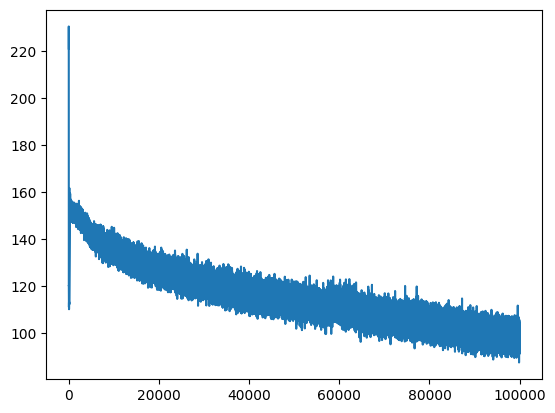

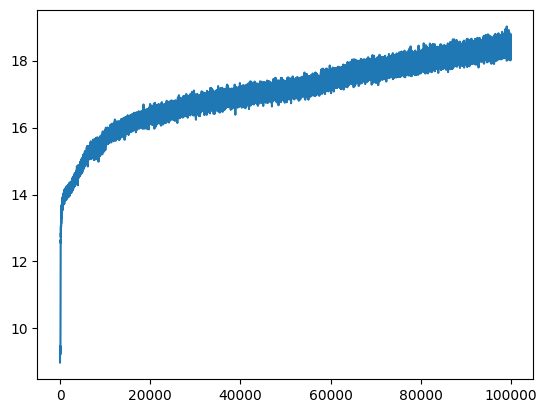

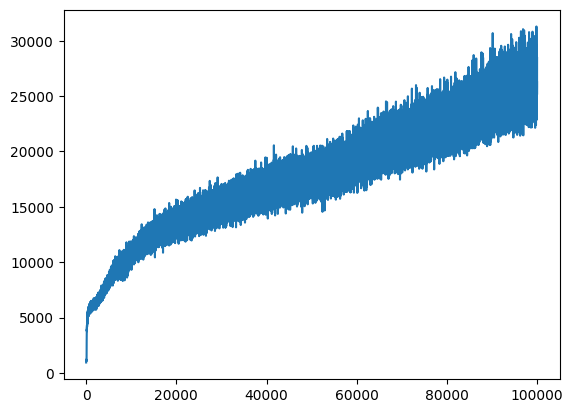

{'entropy_loss': Array(-0.2118575, dtype=float32), 'policy_loss': Array(0.00109087, dtype=float32), 'value_loss': Array(95.88208, dtype=float32)}


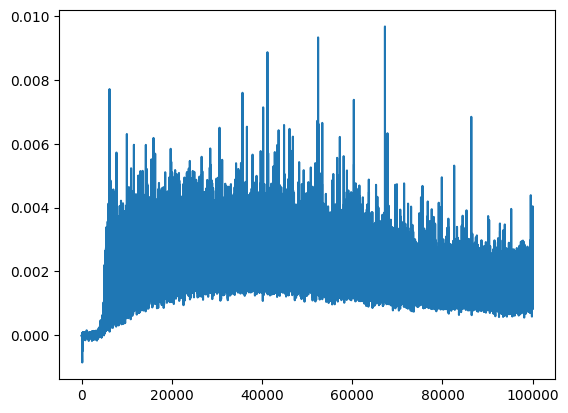

In [172]:
plt.plot(losses)
plt.show()
plt.plot(rewards)
plt.show()
plt.plot(alternate_rewards)
plt.show()
plt.plot(policy_losses)
print(metrics)

In [173]:
jnp.sum(traj.rewards) / jnp.sum(traj.dones)

Array(26259.117, dtype=float32)

In [174]:
jax.tree_util.tree_map(jnp.mean, (loss, metrics))

(Array(95.88105, dtype=float32),
 {'entropy_loss': Array(-0.2118575, dtype=float32),
  'policy_loss': Array(0.00109087, dtype=float32),
  'value_loss': Array(95.88208, dtype=float32)})